In [1]:
import numpy as np
from skimage import io, util, measure, transform, draw
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from imageUtils import normalize_image_intensity_signed

from os import path
import stackview
import matplotlib.pyplot as plt
import seaborn as sb
from glob import glob
from scipy.interpolate import NearestNDInterpolator

from measurements import get_mesh_from_bm_image, export_mesh, get_tissue_curvature_over_grid,get_tissue_curvature_sparse, \
    get_bm_image

from trimesh import Trimesh
import pyvista as pv
pv.set_jupyter_backend('trame')

%load_ext autoreload
%autoreload 2


In [2]:
dirname = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/'

In [12]:
k10_resliced[0,...]

(1013, 1013)

In [15]:
# Construct slicer
Nslice = 30
shift = 15

k10 = io.imread(path.join(dirname,'Aligned channels/G.tif'))[3,...]
mem = io.imread(path.join(dirname,'Aligned channels/R.tif'))[3,...]
height_image = io.imread(path.join(dirname,f'Aligned channels/height_images/t3.tif'))
heightmap = height_image.argmax(axis=0) + 79

k10_resliced = np.zeros((Nslice,*heightmap.shape),dtype=np.uint16)
mem_resliced = np.zeros((Nslice,*heightmap.shape),dtype=np.uint16)

for i in range(Nslice):
    _heightmap = np.clip(heightmap-15+i,a_min=0,a_max=k10.shape[0]-1)
    k10_resliced[i,:,:] = np.take_along_axis(k10, _heightmap[np.newaxis, :, :],axis=0)
    mem_resliced[i,:,:] = np.take_along_axis(mem, _heightmap[np.newaxis, :, :],axis=0)

io.imsave(path.join(dirname,'k10_resliced_t3.tif'),k10_resliced)
io.imsave(path.join(dirname,'mem_resliced_t3.tif'),mem_resliced)
stackview.switch( {'K10':k10_resliced,'mem':mem_resliced},
                 colormap=['pure_green','pure_yellow'], zoom_factor=0.5, toggleable=True)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/mem_resliced_t3.tif is a low contrast image
  return func(*args, **kwargs)


In [20]:
# Normalize by mean basal layer K10 intensity

basal_ranges = np.arange(4,22)

k10_resliced = io.imread(path.join(dirname,'k10_resliced_t3.tif'))
mem_resliced = io.imread(path.join(dirname,'mem_resliced_t3.tif'))

Zbasal = basal_ranges
Ibasal = k10_resliced[Zbasal,:]

k10_resliced_norm = k10_resliced[Zbasal,:].max(axis=0).astype(float)/Ibasal.mean()
io.imsave(path.join(dirname,'k10_resliced_norm_t3.tif'),util.img_as_uint(k10_resliced_norm/k10_resliced_norm.max()))
io.imsave(path.join(dirname,'mem_resliced_basal_t3.tif'),util.img_as_uint(mem_resliced[np.median(Zbasal).astype(int)]))

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/mem_resliced_basal_t3.tif is a low contrast image
  return func(*args, **kwargs)


In [21]:
# Visualize

mem_resliced = io.imread(path.join(dirname,'Prelim analysis/mem_resliced_basal_t3.tif'))
k10_resliced = io.imread(path.join(dirname,'Prelim analysis/k10_resliced_norm_t3.tif'))
stackview.switch( {'K10':k10_resliced,'mem':mem_resliced}, colormap=['pure_green','pure_yellow'],
                 zoom_factor=0.5, toggleable=True)


In [22]:
# filelist = glob(path.join(dirname,'k10_resliced_norm_seg.npy'))
# masks = np.load(filelist[0],allow_pickle=True).item()['masks']
# io.imsave(path.join(dirname,'cp_masks.tif'),masks)
masks = io.imread(path.join(dirname,'Prelim analysis/cp_masks.tif'))

mean_curvature = io.imread(path.join(dirname,'Aligned channels/curvatures/t3.tif'))
if mean_curvature.ndim == 3:
    mean_curvature = mean_curvature[0,...]

stackview.slice(mean_curvature.T,zoom_factor=0.4)

In [53]:
np.median(k10_resliced)

np.float64(0.0)

In [4]:

k10_resliced = io.imread(path.join(dirname,'Prelim analysis/k10_resliced_norm_t3.tif'))
k10_resliced = k10_resliced- np.median(k10_resliced)
k10_resliced[k10_resliced < 0] = 0

df = pd.DataFrame(measure.regionprops_table(masks,intensity_image=k10_resliced,
                                            properties=['label','area','centroid','intensity_max'])).set_index('label')
df = df.rename(columns={'intensity_max':'k10'})
df2 = pd.DataFrame(measure.regionprops_table(masks,intensity_image=mean_curvature.T,
                                             properties=['label','intensity_mean'])).set_index('label')
df2 = df2.rename(columns={'intensity_mean':'curvature'})
df = pd.merge(df,df2,left_index=True,right_index=True)

df['Log-K10'] = np.log(df['k10'])
# zeros = df[np.abs(df['curvature'] - 0) < 1e-3]
df = df[np.abs(df['curvature'] - 0) > 1e-3]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Time course/Prelim analysis/k10_resliced_norm_t3.tif'

In [69]:
zeros = df[np.abs(df['curvature'] - 0) < 1e-3]
zeros

,area,centroid-0,centroid-1,k10,curvature,Log-K10
label,,,,,,


In [70]:
df.loc[[663,666,674,690,638]][['Log-K10','curvature']]

,Log-K10,curvature
label,,
663,10.489467,0.051185
666,10.471723,0.004111
674,9.453365,0.071087
690,9.173884,-0.001738
638,9.279027,-0.194599


PearsonRResult(statistic=np.float64(-0.13685762975982457), pvalue=np.float64(3.760629446157195e-05))

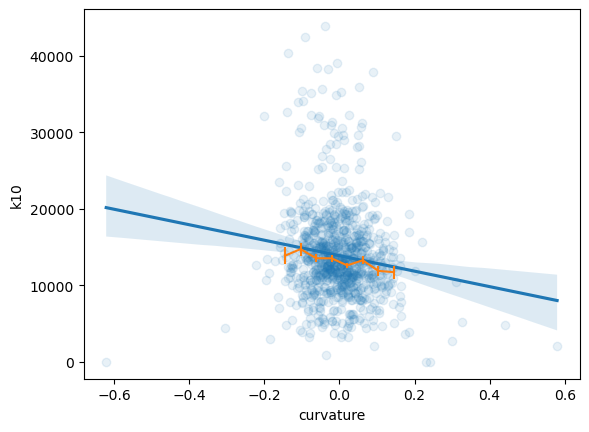

In [82]:
from basicUtils import nonan_pairs,plot_bin_means
from scipy import stats

sb.regplot(df,y='k10',x='curvature',scatter_kws={'alpha':0.1})
X,Y = nonan_pairs(df['curvature'],df['k10'])
plot_bin_means(X,Y,bin_edges=30)
stats.pearsonr(X,Y)

# sb.regplot(zeros,y='Log-K10',x='curvature',scatter_kws={'alpha':0.1})

In [92]:
df

,area,centroid-0,centroid-1,k10,curvature,Log-K10,K10-minus,Concavity
label,,,,,,,,
5,100.0,3.700000,777.280000,4464.0,-0.303754,8.403801,True,False
24,747.0,48.803213,802.661312,5636.0,0.037983,8.636930,True,True
27,1102.0,63.990018,695.710526,6895.0,0.080521,8.838552,True,True
28,850.0,60.838824,648.243529,8354.0,0.078221,9.030496,True,True
30,857.0,57.303384,846.024504,6060.0,0.078913,8.709465,True,True
...,...,...,...,...,...,...,...,...
1096,1.0,1011.000000,424.000000,4780.0,0.440524,8.472196,True,True
1097,906.0,359.057395,449.997792,31010.0,-0.022536,10.342065,True,False
1098,1257.0,507.939539,314.941130,17340.0,0.045771,9.760771,True,True


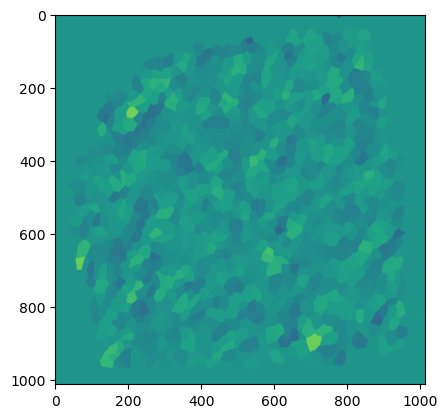

In [103]:
from skimage import morphology
# masks_eroded = morphology.erosion(masks,footprint=morphology.disk(10))
masks_eroded = np.zeros_like(masks,dtype=float)

for label in df.index:
    masks_eroded[masks == label] = df.loc[label]['curvature']

io.imsave(path.join(dirname,'cp_masks_eroded.tif'),masks_eroded)
plt.imshow(masks_eroded)

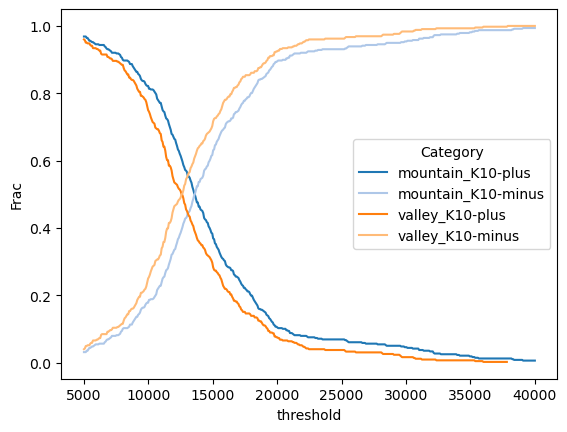

In [83]:
concavity_dict = {True:'valley',False:'mountain'}
k10_dict = {True:'K10-minus',False:'K10-plus'}

counts = []
for th in np.linspace(5000,40000,500):
    df['K10-minus'] = df['k10'] < th
    df['Concavity'] = df['curvature'] > 0
    # _df = df.groupby(['Concavity','K10-minus'])['area'].count()
    _df = pd.DataFrame(df.groupby(['Concavity','K10-minus'])['area'].count()).T.melt()
    _df.loc[_df['Concavity'],'value'] /= _df.loc[_df['Concavity'],'value'].sum()
    _df.loc[~_df['Concavity'],'value'] /= _df.loc[~_df['Concavity'],'value'].sum()
    
    _df['Category'] = _df['Concavity'].map(concavity_dict) + '_' + _df['K10-minus'].map(k10_dict)
    _df = _df.drop(columns=['Concavity','K10-minus'])
    _df = _df.rename(columns={'value':'Frac'})
    # _df['Frac'] /= len(df)
    _df['threshold'] = th
    counts.append(_df)

counts = pd.concat(counts,ignore_index=True)
counts
plt.figure()
sb.lineplot(counts,x='threshold',y='Frac',hue='Category',
           hue_order=['mountain_K10-plus','mountain_K10-minus','valley_K10-plus','valley_K10-minus'],
           palette='tab20')
plt.show()

(-0.3, 0.3)

<Figure size 640x480 with 0 Axes>

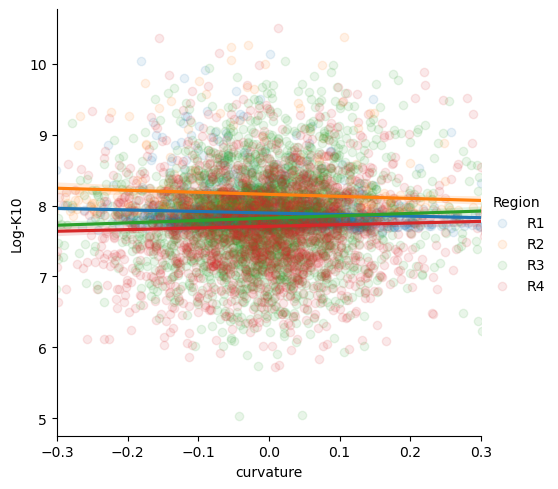

<Figure size 640x480 with 0 Axes>

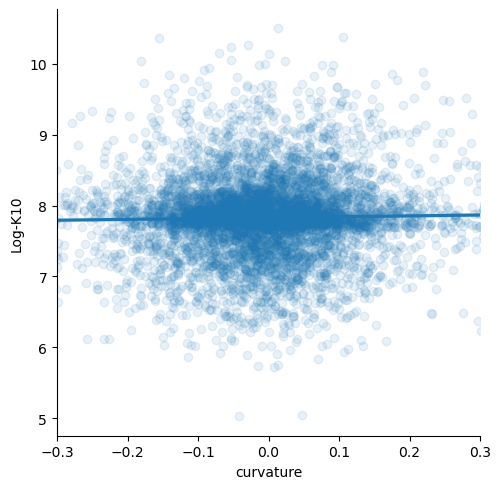

In [24]:
plt.figure()
sb.lmplot(all_df,x='curvature',y='Log-K10',hue='Region',scatter_kws={'alpha':0.1})
plt.xlim([-.3,.3])
# plt.ylim([0,10000])

plt.figure()
sb.lmplot(all_df,x='curvature',y='Log-K10',scatter_kws={'alpha':0.1})
plt.xlim([-.3,.3])
# plt.ylim([0,10000])


## Gate K10- v. K10+ cells

<Axes: xlabel='k10', ylabel='Count'>

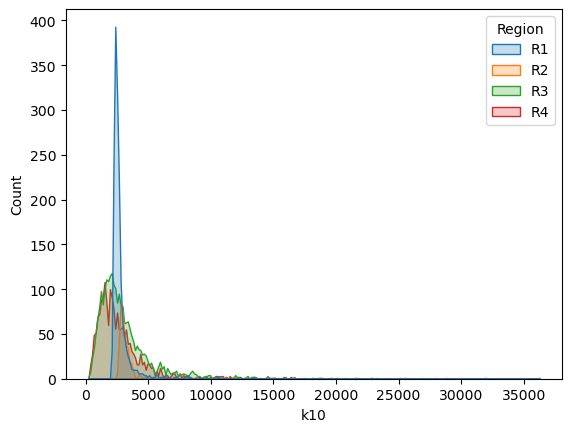

In [26]:
sb.histplot(all_df,x='k10',hue='Region',element='poly')


# More manual approach?

In [514]:
import pandas as pd
from skimage import measure, filters
import seaborn as sb
from basicUtils import plot_bin_means

masks = np.load(path.join(dirname,'mem_resliced_z7_seg.npy'),allow_pickle=True).item()['masks']
# masks = io.imread(path.join(dirname,'mem_resliced_z3_masks.tif')) * mask

# k10_max = (k10[5,...]).max(axis=0).astype(float)*mask
k10_max = k10_resliced[18,...]

df = pd.DataFrame(measure.regionprops_table(masks,intensity_image=k10_max,properties=['label','intensity_mean']))
df = df.set_index('label').rename(columns={'intensity_mean':'k10'})
df_ = pd.DataFrame(measure.regionprops_table(masks,intensity_image=curvature,properties=['label','intensity_mean']))
df_ = df_.set_index('label').rename(columns={'intensity_mean':'curvature'})
# df_ = pd.DataFrame(measure.regionprops_table(masks,intensity_image=gaussian_curvautre,properties=['label','intensity_mean']))
# df_ = df_.set_index('label').rename(columns={'intensity_mean':'gaussian_curvature'})

df = pd.merge(df,df_,left_index=True,right_index=True)
df['log-k10'] = np.log(df['k10'])
sb.scatterplot(df,y='k10',x='curvature',alpha=0.1)
plot_bin_means(df['curvature'],df['k10'],bin_edges=20,minimum_n=20,color='r',mean='median')

df.to_csv(path.join(dirname,'data_frame.csv'))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped/mem_resliced_z7_seg.npy'

In [162]:
stackview.switch({'k10':k10_max*mask,
                    'mean':curvature},
                colormap=['pure_green','pure_magenta'],
                toggleable=True)

NameError: name 'k10_max' is not defined

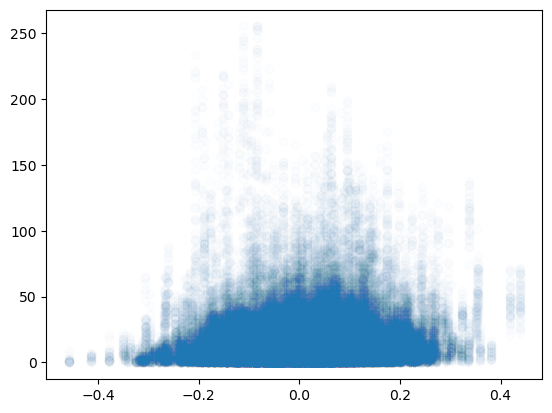

In [385]:
plt.scatter((curvature*mask).flatten(),(k10_resliced[18,...]*mask).flatten(),alpha=0.01)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


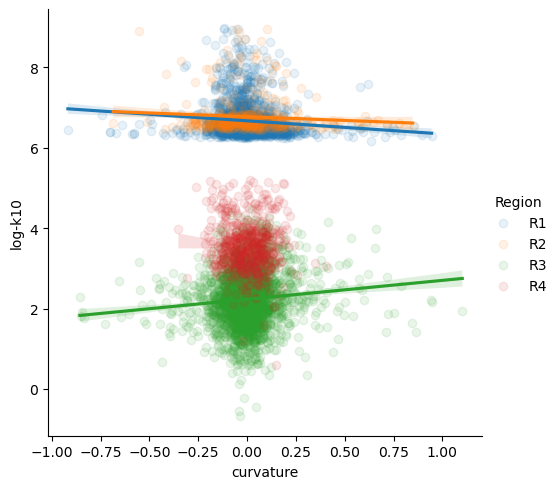

In [387]:
df1 = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R1/Uncropped/data_frame.csv',index_col='label')
df1['Region'] = 'R1'
df2 = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R2/Cropped/data_frame.csv',index_col='label')
df2['Region'] = 'R2'
df3 = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R4/Cropped/data_frame.csv',index_col='label')
df3['Region'] = 'R3'
df4= pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/K10-R7/Cropped/data_frame.csv',index_col='label')
df4['Region'] = 'R4'
df = pd.concat((df1,df2,df3,df4),ignore_index=True)
sb.lmplot(df,x='curvature',y='log-k10',hue='Region',scatter_kws={'alpha':0.1})
# plot_bin_means(df['curvature'],df['log-k10'],bin_edges=40,minimum_n=50,mean='mean',color='r')
# plt.xlim([-.5,.5])
# plt.ylim([6,8])

plt.gcf().savefig(path.join('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Two photon/Shared/K10 paw/Figures/k10_v_curvature.svg'))

In [85]:
from scipy import stats

stats.pearsonr(df['curvature'],df['log-k10'])

PearsonRResult(statistic=np.float64(-0.09783836887916617), pvalue=np.float64(2.9066975143682647e-06))

In [255]:
# Load resliced 3D manually gated cells

In [334]:
k10_plus = pd.read_csv(path.join(dirname,'K10+.csv'),index_col=0)
k10_minus = pd.read_csv(path.join(dirname,'K10-.csv'),index_col=0)

resliced_masks = io.imread(path.join(dirname,'mem_resliced_cp_masks.tif'))
resliced_k10 = io.imread(path.join(dirname,'k10_resliced.tif'))
resliced_k10_sub = resliced_k10.copy() - filters.threshold_otsu(resliced_k10)
resliced_k10_sub[resliced_k10_sub < 0] = 0
mean_curvature = np.load(path.join(dirname,'mean_curvature.npz'))['mean_curvature'][0,...]
df = pd.DataFrame(measure.regionprops_table(resliced_masks,intensity_image=resliced_k10_sub,properties=['area','centroid','label','mean_intensity']))

In [335]:
# Filter for cells of interest

for idx,centroid in k10_plus.iterrows():
    Z,Y,X = centroid[['axis-0','axis-1','axis-2']].astype(int)
    l = resliced_masks[Z,Y,X]
    if l > 0:
        df.loc[df['label'] == l, 'K10'] = 'Plus'
        df.loc[df['label'] == l, 'Mean curvature'] = mean_curvature[Y,X]

for idx,centroid in k10_minus.iterrows():
    Z,Y,X = centroid[['axis-0','axis-1','axis-2']].astype(int)
    l = resliced_masks[Z,Y,X]
    if l > 0:
        df.loc[df['label'] == l, 'K10'] = 'Minus'
        df.loc[df['label'] == l, 'Mean curvature'] = mean_curvature[Y,X]


In [336]:
df.groupby('K10').count()

,area,centroid-0,centroid-1,centroid-2,label,mean_intensity,Mean curvature
K10,,,,,,,
Minus,121,121,121,121,121,121,121
Plus,66,66,66,66,66,66,66


In [163]:
stackview.switch({'k10':resliced_k10,'curv':mean_curvature},zoom_factor=0.5,colormap=['pure_green','pure_magenta'])

NameError: name 'resliced_k10' is not defined

In [338]:
stackview.slice(mean_curvature,zoom_factor=0.5)

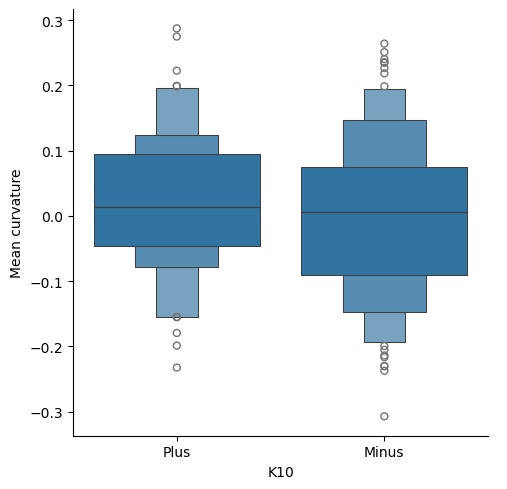

In [339]:
sb.catplot(df.dropna(subset='K10'),x='K10',y='Mean curvature',kind='boxen')